### Proceso de Clusterizacion de PyPSA

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers
INFO:pypsa.io:Imported network elec_s_9_ec_lv1_1H_demand.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
c:\Users\ariel\mambaforge\Library\envs\pypsa-earth\Lib\site-packages\pyogrio\__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


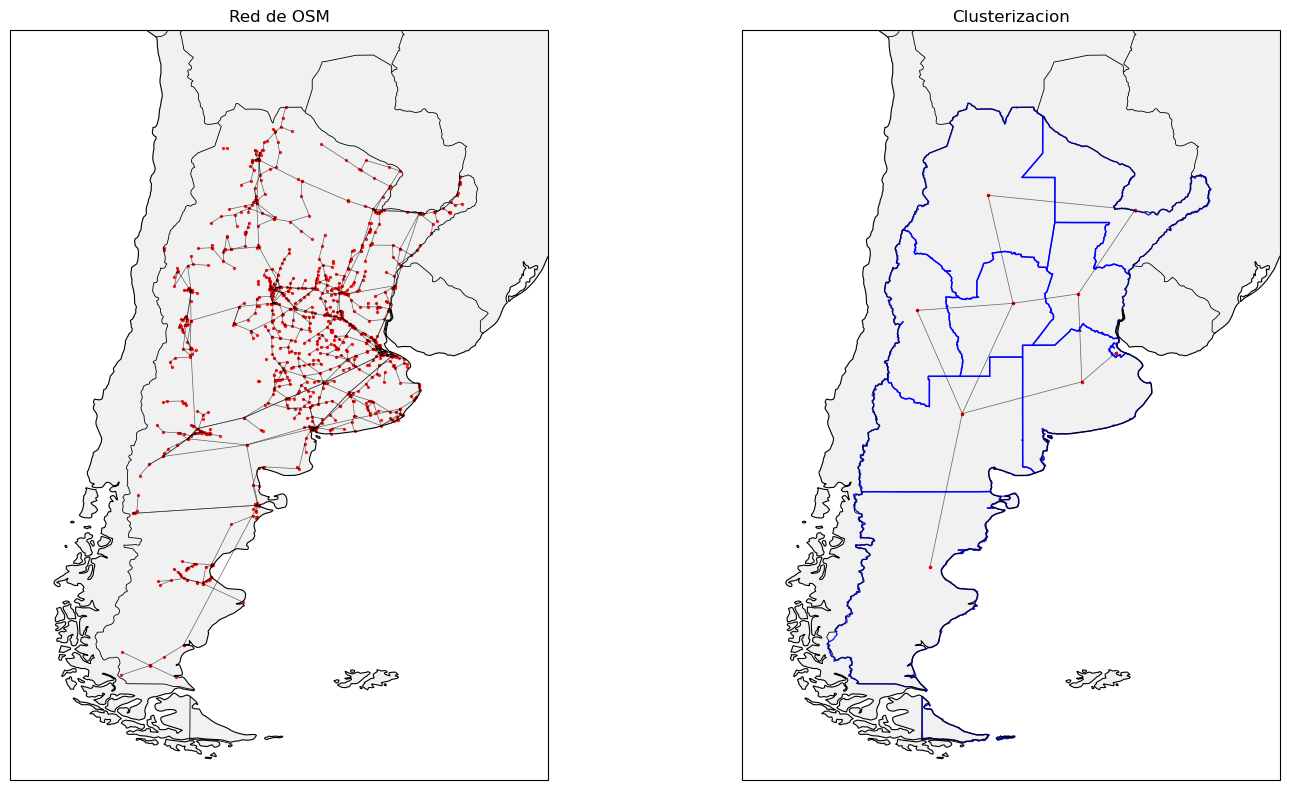

Realistic grid: buses = 940 lines = 1041
Final grid:      buses = 27 lines = 11


In [ ]:
import geopandas as gpd
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- FILE PATHS ----
base_path = #RED
realistic_nc = base_path + r"\elec.nc"
final_nc     = base_path + r"\elec_s_9_ec_lv1_1H_demand.nc"

regions_geojson = argentina_regiones.geojson

# ---- LOAD NETWORKS ----
n_real  = pypsa.Network(realistic_nc)
n_final = pypsa.Network(final_nc)

# ---- LOAD REGIONS ----
gdf_regions = gpd.read_file(regions_geojson).to_crs(epsg=4326)

def plot_network_cartopy(n, ax, title, regions_gdf=None):
    buses = n.buses.dropna(subset=["x", "y"])
    lines = n.lines[
        n.lines.bus0.isin(buses.index) &
        n.lines.bus1.isin(buses.index)
    ]

    # Plot lines
    for _, l in lines.iterrows():
        x = [buses.loc[l.bus0, "x"], buses.loc[l.bus1, "x"]]
        y = [buses.loc[l.bus0, "y"], buses.loc[l.bus1, "y"]]
        ax.plot(x, y, transform=ccrs.PlateCarree(), color="black", linewidth=0.5, alpha=0.6)

    # Plot buses
    ax.scatter(buses.x, buses.y, transform=ccrs.PlateCarree(), s=2, color="red", alpha=0.8)

    # Regions boundaries
    if regions_gdf is not None:
        ax.add_geometries(
            regions_gdf.geometry,
            crs=ccrs.PlateCarree(),
            facecolor="none",
            edgecolor="blue",
            linewidth=1.0,
            alpha=0.9,
        )

    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    ax.set_extent([-78, -50, -57, -18], crs=ccrs.PlateCarree())
    ax.set_title(title)

# ---- FIGURE ----
fig = plt.figure(figsize=(16, 8))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

plot_network_cartopy(n_real,  ax1, "Red de OSM")
plot_network_cartopy(n_final, ax2, "Clusterizacion", regions_gdf=gdf_regions)

plt.tight_layout()
plt.show()

print("Realistic grid: buses =", len(n_real.buses), "lines =", len(n_real.lines))
print("Final grid:      buses =", len(n_final.buses), "lines =", len(n_final.lines))


### Mapa nombres lineas

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores
c:\Users\ariel\mambaforge\Library\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


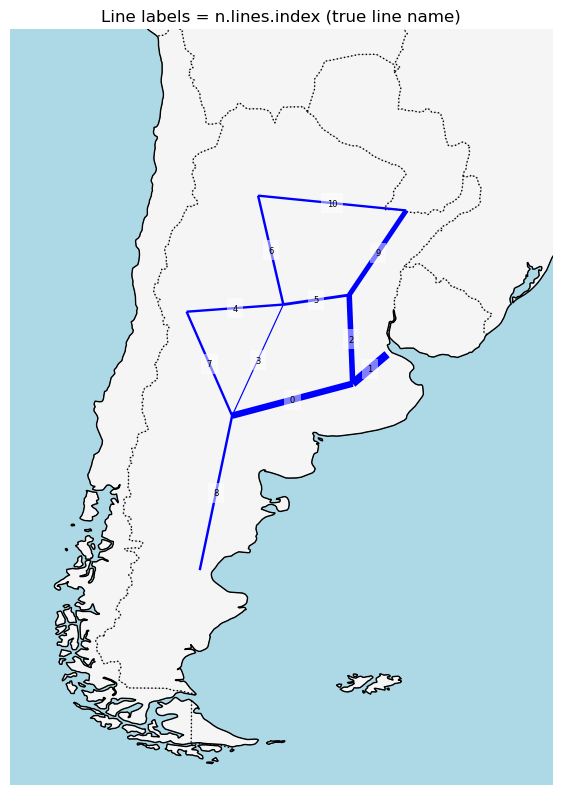

In [ ]:
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

n = #RED

fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={"projection": ccrs.PlateCarree()})

n.plot(
    ax=ax,
    branch_components=["Line"],
    line_widths=0.8 + n.lines.s_nom / 2500.0,
    line_colors="blue",
    bus_sizes=0,
    color_geomap=True
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_xlim([-78, -50])
ax.set_ylim([-57, -18])
ax.set_title("Line labels = n.lines.index (true line name)")

# Label with the TRUE line name (index), not positional row number
for line in n.lines.itertuples():
    lon = 0.5 * (n.buses.loc[line.bus0, "x"] + n.buses.loc[line.bus1, "x"])
    lat = 0.5 * (n.buses.loc[line.bus0, "y"] + n.buses.loc[line.bus1, "y"])

    ax.text(
        lon, lat,
        str(line.Index),   # <-- this is the line name, e.g. "37"
        color="black",
        fontsize=6,
        ha="center",
        va="center",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.5)
    )

plt.show()

### Mapa carga lineas

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores
c:\Users\ariel\mambaforge\Library\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


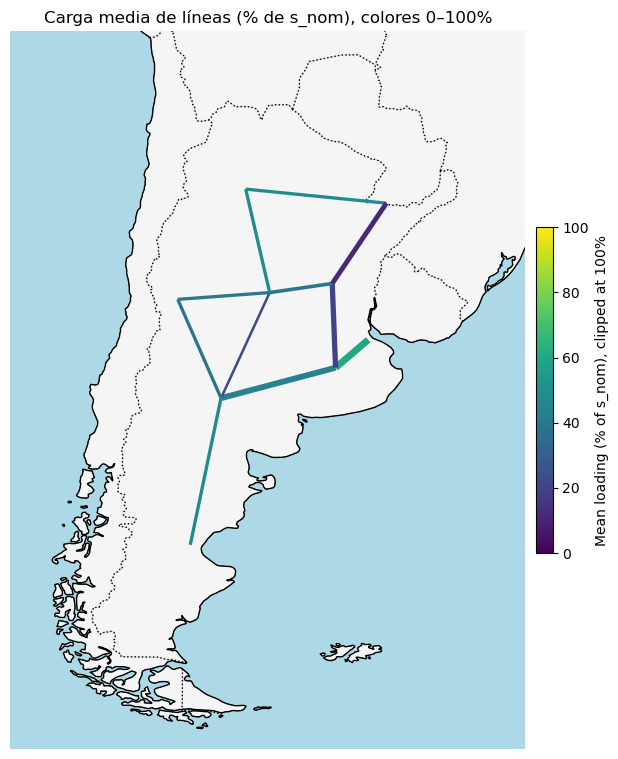

In [ ]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- LOAD SOLVED NETWORK ---
n1 = #RED

# --- CAPACITY (NO EXPANSION): s_nom ---
s_nom = n1.lines["s_nom"].replace(0, np.nan)

# --- MEAN LOADING (% of s_nom), robust ---
flow_abs = np.maximum(n1.lines_t.p0.abs(), n1.lines_t.p1.abs())
mean_loading_pct = 100.0 * (flow_abs.div(s_nom, axis=1).mean(axis=0))
mean_loading_pct = mean_loading_pct.clip(lower=0.0, upper=100.0)

# Align explicitly
line_colors = mean_loading_pct.reindex(n1.lines.index).fillna(0.0)

# --- MUCH MORE VISIBLE LINE WIDTHS ---
# Stronger base + softer capacity scaling
line_widths = 1.8 + (n1.lines.s_nom / 4000.0)
line_widths = line_widths.clip(lower=1.8)

# --- COLOR NORMALIZATION ---
norm = colors.Normalize(vmin=0.0, vmax=100.0)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={"projection": ccrs.PlateCarree()})

n1.plot(
    ax=ax,
    branch_components=["Line"],
    line_widths=line_widths,
    line_colors=line_colors,
    line_cmap=plt.cm.viridis,
    line_norm=norm,
    bus_sizes=0,
    bus_colors="gray",
    color_geomap=True
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_xlim([-78, -50])
ax.set_ylim([-57, -18])
ax.set_title("Carga media de líneas (% de s_nom), colores 0–100%")

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Mean loading (% of s_nom), clipped at 100%")
cbar.set_ticks([0, 20, 40, 60, 80, 100])

plt.show()

### Tabla carga media y maxima de cada linea

In [4]:
import pandas as pd
import numpy as np

# --- capacity (no expansion): use s_nom ---
s_nom = n.lines["s_nom"].replace(0, np.nan)

# --- line flows (MW) ---
p0 = n.lines_t.p0  # snapshots x lines

# --- Mean loading over all snapshots (% of s_nom) ---
loading = p0.abs().div(s_nom, axis=1)  # per-unit of s_nom
mean_loading_pct = 100 * loading.mean(axis=0)

# --- Peak loading (% of s_nom) ---
peak_flow = p0.abs().max(axis=0)  # MW
peak_loading_pct = 100 * (peak_flow / s_nom)

# --- output table ---
out = pd.DataFrame({
    "Line": n.lines.index,
    "Mean Loading (%)": mean_loading_pct.values,
    "Peak Loading (%)": peak_loading_pct.values
})

# Sort numerically by converting Line to int (if possible)
try:
    out = out.sort_values("Line", key=lambda x: x.astype(int))
except:
    out = out.sort_values("Line")  # Fall back to alphabetical if conversion fails

out = out.reset_index(drop=True)

# --- show ALL rows in notebook WITHOUT the index ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(out.style.hide(axis='index'))

Line,Mean Loading (%),Peak Loading (%)
0,44.462361,99.999999
1,59.798436,100.000004
2,19.891844,75.528124
3,22.977950,87.217739
4,39.625407,99.999999
5,39.067415,100.000010
6,48.184218,99.999996
7,38.435710,99.999997
8,48.032287,99.999999
9,11.237417,35.744028


### Carga de Linea Individual

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units


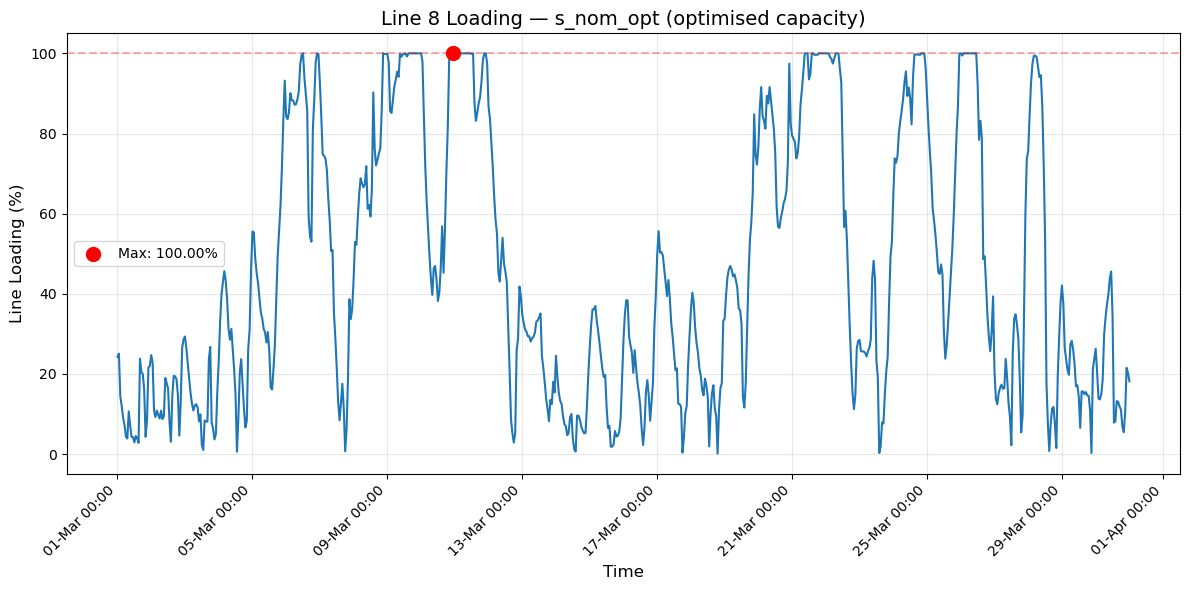


Line 8 Loading Statistics (2013-03-01 00:00:00 to 2013-03-31 00:00:00):
  s_nom_opt: 2381.81 MW
  Mean:  45.95%
  Max:   100.00% at 2013-03-10 23:00:00
  Min:   0.10%


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import pypsa

n = #RED

# Choose the line you want to plot
line_name = "8"  # Change this to the line you want to visualize

# Choose time window
start = pd.Timestamp("2013-03-01 00:00:00")
end   = pd.Timestamp("2013-03-31 00:00:00")

# --- capacity (with expansion): use s_nom_opt ---
s_nom_opt = n.lines["s_nom_opt"].replace(0, np.nan)

# --- line flows (MW) ---
p0 = n.lines_t.p0  # snapshots x lines

# --- Calculate loading as percentage ---
loading_pct = 100 * p0.abs().div(s_nom_opt, axis=1)

# --- Extract data for the selected line ---
line_loading = loading_pct[line_name]

# --- Filter by time window ---
line_loading_filtered = line_loading.loc[start:end]

# --- Find max loading and its timestamp ---
max_loading = line_loading_filtered.max()
max_loading_time = line_loading_filtered.idxmax()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(line_loading_filtered.index, line_loading_filtered.values, linewidth=1.5)

# Mark the maximum point
ax.scatter(max_loading_time, max_loading, color='red', s=100, zorder=5,
           label=f'Max: {max_loading:.2f}%')
ax.axhline(y=max_loading, color='red', linestyle='--', alpha=0.3)

# Format x-axis
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b %H:%M'))
plt.xticks(rotation=45, ha='right')

# Suppress scientific notation on y-axis
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Line Loading (%)', fontsize=12)
ax.set_title(f'Line {line_name} Loading — s_nom_opt (optimised capacity)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nLine {line_name} Loading Statistics ({start} to {end}):")
print(f"  s_nom_opt: {n.lines.loc[line_name, 's_nom_opt']:.2f} MW")
print(f"  Mean:  {line_loading_filtered.mean():.2f}%")
print(f"  Max:   {max_loading:.2f}% at {max_loading_time}")
print(f"  Min:   {line_loading_filtered.min():.2f}%")